# Zero-Train Optimization & Maintenance (ZTOM) of a Legal Understanding LLM

----
## The Problem

> Every time you fine-tune a model for a new task, you risk breaking existing capabilities.  
> Fixing that usually means **retraining** — which is expensive, slow, and hard to debug.

This demo shows how you can use Authentrics and solve it **without retraining**.

---

## Demo Scenario

We walk through a realistic production scenario:

1. Train a model for **legal contract understanding**  
2. Add a new capability (**summarization**)  
3. Observe **regression in the original task**  
4. Detect *where and how* the model changed  
5. Fix the issue using **ZTOM — no retraining required**

---

## Model Setup

- **Base model:** [Gemma 3 1B IT](https://huggingface.co/google/gemma-3-1b-it) — (instruction-tuned)
- **Adaptation:** LoRA adapters via [Hugging Face PEFT](https://huggingface.co/docs/peft)  
- **Why this setup:**
  - Efficient fine-tuning
  - Standard industry approach
  - Enables clean comparison across checkpoints

---

## Fine-Tuning Tasks

### Task A — Contract Understanding (Primary Capability)

- Dataset: : CUAD as QA over contracts; [CUAD paper](https://arxiv.org/abs/2103.06268).  
- Objective: Answer questions over legal contracts  

---

### Task B — Legal Bill Summarization (New Capability)

- Dataset: :[BillSum](https://huggingface.co/datasets/billsum) — long bills with human summaries.
- Objective: Generate concise summaries from long Legal Documents  
- Evaluation: ROUGE (ROUGE-1 / ROUGE-L)

---
### Impact of Task B training on Task A (TODO: Modify the stats or image accordingly)
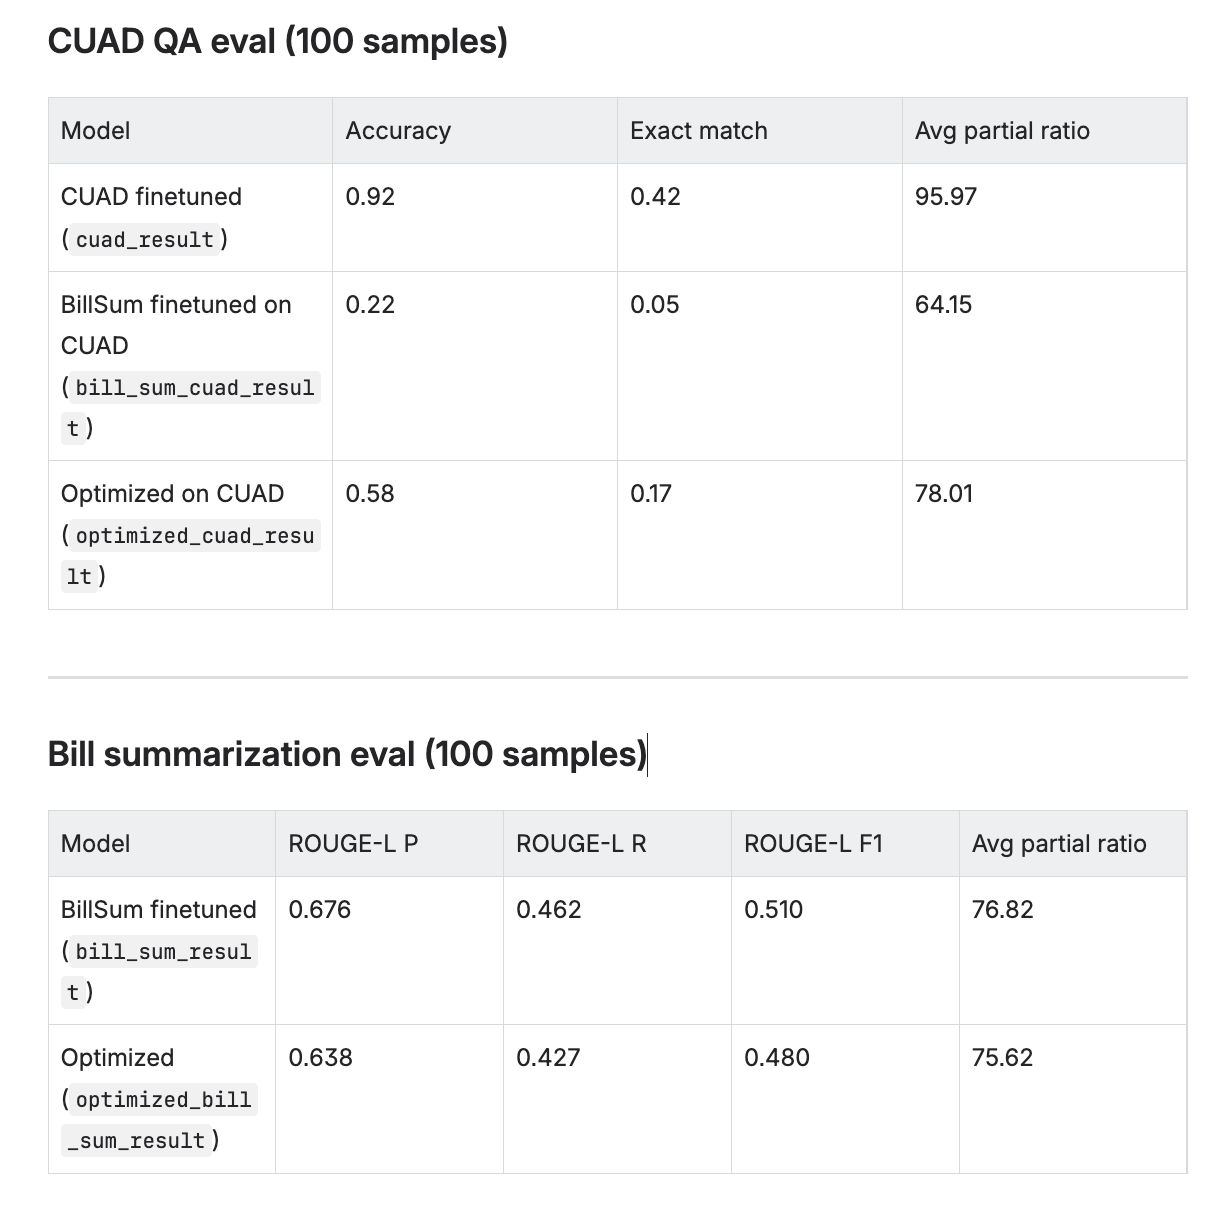



## Why This Matters

In production systems:

- Models are **continuously updated** with new capabilities  
- Each update risks **silent regressions**  
- Retraining:
  - ❌ expensive (GPU + time)
  - ❌ non-deterministic
  - ❌ no visibility into *what actually changed*

 **This is the gap ZTOM addresses**.
 

---

## What is ZTOM?

**Zero-Train Optimization & Maintenance (ZTOM)** directly adjusts a model’s behavior:

- ✅ No retraining
- ✅ No additional data required  
- ✅ Works on existing checkpoints  
- ✅ Targets *specific behavioral drift*

Instead of:
> “Retrain the entire model and hope it improves”

We:
> “Identify the exact change and correct it”

---

## Optimization Objective

Authentrics optimizes using **custom loss function** and **small sample of datasets** that is given by the user:
In this demo, the optimization objective is to improve the latest model for CUAD accuracy 
while maintaining the accuracy for bill summarization post training. 

- Metric: Mean RapidFuzz `partial_ratio`  
- Compared against: `dataset["answer"]`  
- Goal: **maximize similarity** (`minimize=False`)

---

## 📈 Results

ZTOM improves model performance **without retraining**:

| Metric | Value |
|--------|------:|
| **Objective** | Mean RapidFuzz `partial_ratio` vs. `dataset["answer"]` (higher is better) |
| **Optimizer** | `minimize=False` (maximize objective) |
| **Scaling factors** | `[-0.262, 0.084, 0.999, -0.614, -0.226, 0.765, -0.215, 0.577, 0.276]` |
| **Original objective** | 31.227872848510742 |
| **Best objective** | 59.72260665893555 |
| **Relative improvement** | ~91% vs. original \((\text{best}-\text{original})/\text{original}\) |
| **Number of evaluations** | 100 |
---

## 💡 Key Takeaway

> We are not retraining the model.  
> We are **correcting it**.

ZTOM enables:
- Faster iteration cycles  
- Lower infrastructure cost  
- Precise control over model behavior  

---

## 🧠 (Optional Deep Dive — for advanced users)

Under the hood:
- Layer-level changes are analyzed across checkpoints  
- Optimization targets specific behavioral deltas  
- Scaling factors are applied selectively across model components  

This detail is **not required to use the system**, but available for deeper inspection.

Copy paste the actual demo code here 